In [1]:
using Pkg
Pkg.activate("./")

  Activating project at `~/research/SecretTamboMC.jl/notebooks/make_triangulated_earth`


In [2]:
using Makie
using CairoMakie
using GMT
using Distributions
using HDF5
using LinearAlgebra
using Rotations

# Make triangulation of the Earth
## Sample points of different densities

In reality, we will need many, many more points than this, but sampling that densely makes visualization very hard.
This suffices for now.
We have also grossly exaggrated the distance scales for the same reason.

In [3]:
rearth = 6_378_000 # m
θtrans1, θtrans2 = 250_000 / rearth, 1_000_000 / rearth
N1, N2, N3 = 1_000, 1_000, 1_000

sample_points = zeros((N1 + N2 + N3, 2))

for idx in 1:N1
    sinlat = rand(Uniform(cos(θtrans1), 1))
    long = 2π * rand()
    sample_points[idx, :] = [long, asin(sinlat)]
end
    
for idx in 1:N2
    sinlat = rand(Uniform(cos(θtrans2), cos(θtrans1)))
    long = 2π * rand()
    sample_points[idx + N1, :] = [long, asin(sinlat)]
end
    
for idx in 1:N3
    sinlat = rand(Uniform(-1, cos(θtrans2)))
    long = 2π * rand()
    sample_points[idx + N1 + N2, :] = [long, asin(sinlat)]
end     

## Run the triangulation and display it

  0.131507 seconds (438.10 k allocations: 21.738 MiB, 78.49% compilation time)


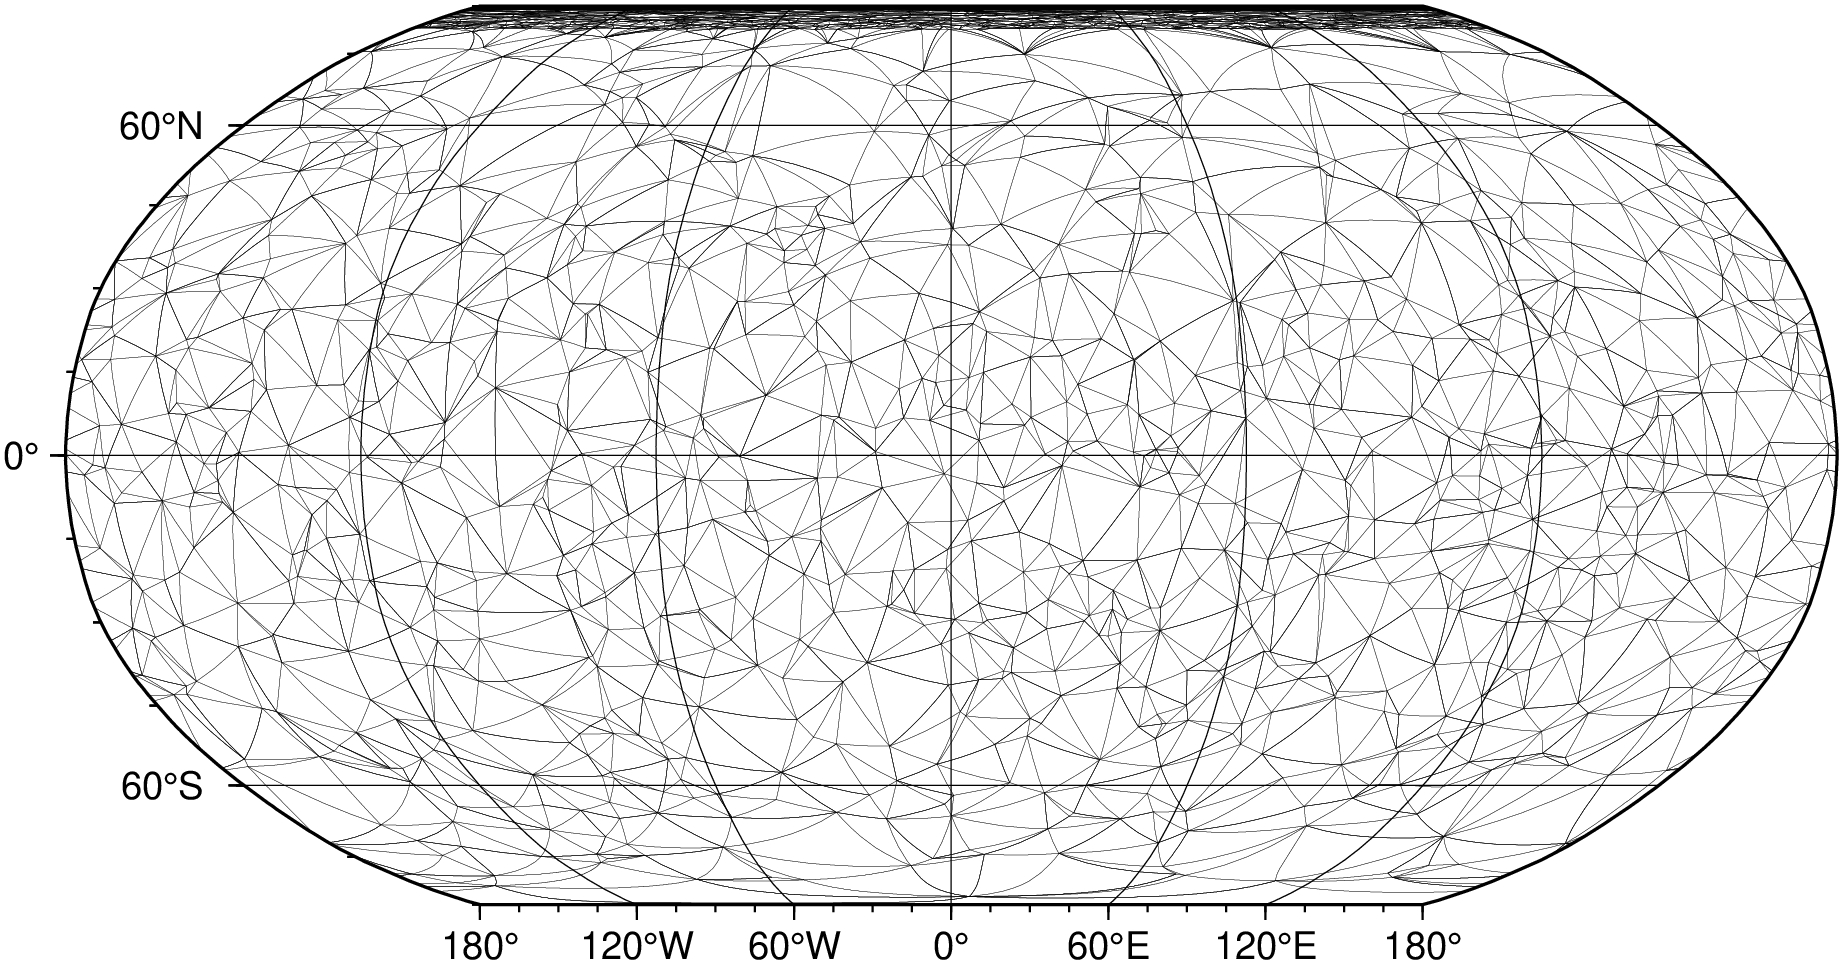

nothing

In [4]:
@time triangulation = sphtriangulate(rad2deg.(sample_points), area=true, unit=:km)
m = imshow(triangulation, region=:global, proj=:guess, frame=:afg, pen=0.002)
display(m);

# To get any reasonable spatial resolution, we need to change the parameters
We will make the near and middle regions smaller, and increase the number of points that we consider

## First, let's do a quick study to understand the scaling

In [5]:
function spherical_triangle_area(p1, p2, p3, radius=1.0)
    """
    Calculate area of spherical triangle using spherical excess
    
    Args:
        p1, p2, p3: Points as (longitude, latitude) in degrees
        radius: Sphere radius (default: unit sphere)
    
    Returns:
        Area on sphere surface
    """
    # Convert to radians
    lon1, lat1 = deg2rad.(p1)
    lon2, lat2 = deg2rad.(p2)
    lon3, lat3 = deg2rad.(p3)
    
    # Calculate side lengths (angular distances) using spherical law of cosines
    a = acos(sin(lat2) * sin(lat3) + cos(lat2) * cos(lat3) * cos(lon3 - lon2))
    b = acos(sin(lat3) * sin(lat1) + cos(lat3) * cos(lat1) * cos(lon1 - lon3))
    c = acos(sin(lat1) * sin(lat2) + cos(lat1) * cos(lat2) * cos(lon2 - lon1))
    
    # Calculate spherical excess using L'Huilier's formula
    s = (a + b + c) / 2
    a = tan(s/2) * tan((s-a)/2) * tan((s-b)/2) * tan((s-c)/2)
    E = 4 * atan(sqrt(max(a, 0)))
    
    return radius^2 * E
end

spherical_triangle_area (generic function with 2 methods)

In [6]:
function sample_points_on_sphere(Ns::Tuple{Int, Int, Int}, θs::Tuple{Float64, Float64})
    N1, N2, N3 = Ns
    θtrans1, θtrans2 = θs
    
    sample_points = zeros((N1 + N2 + N3, 2))

    for idx in 1:N1
        sinlat = rand(Uniform(cos(θtrans1), 1))
        long = 2π * rand()
        sample_points[idx, :] = [long, asin(sinlat)]
    end

    for idx in 1:N2
        sinlat = rand(Uniform(cos(θtrans2), cos(θtrans1)))
        long = 2π * rand()
        sample_points[idx + N1, :] = [long, asin(sinlat)]
    end

    for idx in 1:N3
        sinlat = rand(Uniform(-1, cos(θtrans2)))
        long = 2π * rand()
        sample_points[idx + N1 + N2, :] = [long, asin(sinlat)]
    end
    return sample_points
end

sample_points_on_sphere (generic function with 1 method)

In [7]:
function calc_centroid(triangle::GMTdataset{Float64, 2})
    centroid = zeros(3)
    for idx in 1:3
        x = longlat_to_cart(deg2rad.(triangle[idx, :])...)
        centroid .+= x
    end
    return centroid ./ 3
end

function longlat_to_cart(long, lat)
    return [cos(long) * cos(lat), sin(long) * cos(lat), sin(lat)]
end

function cart_to_longlat(x, y, z)
    return [atan(y, x), asin(z)]
end

cart_to_longlat (generic function with 1 method)

In [8]:
function compute_triangulaiton_areas(
    triangulation::Vector{GMTdataset{Float64, 2}},
    θs::Tuple{Float64, Float64}
)
    θtrans1, θtrans2 = θs
    areas1, areas2, areas3 = [], [], []
    for triangle in triangulation
        centroid = calc_centroid(triangle)
        θ = acos(dot([0, 0, 1], centroid) / norm(centroid))
        p1 = triangle[1, :]
        p2 = triangle[2, :]
        p3 = triangle[3, :]
        a = spherical_triangle_area(p1, p2, p3, rearth)
        if θ < θtrans1
            push!(areas1, a)
        elseif θ < θtrans2
            push!(areas2, a)
        else
            push!(areas3, a)
        end
    end 
    return areas1, areas2, areas3
end

compute_triangulaiton_areas (generic function with 1 method)

## Warning: running this will take a couple minutes.
You can get the gist by uncommenting the fifth line, which will take <10 seconds

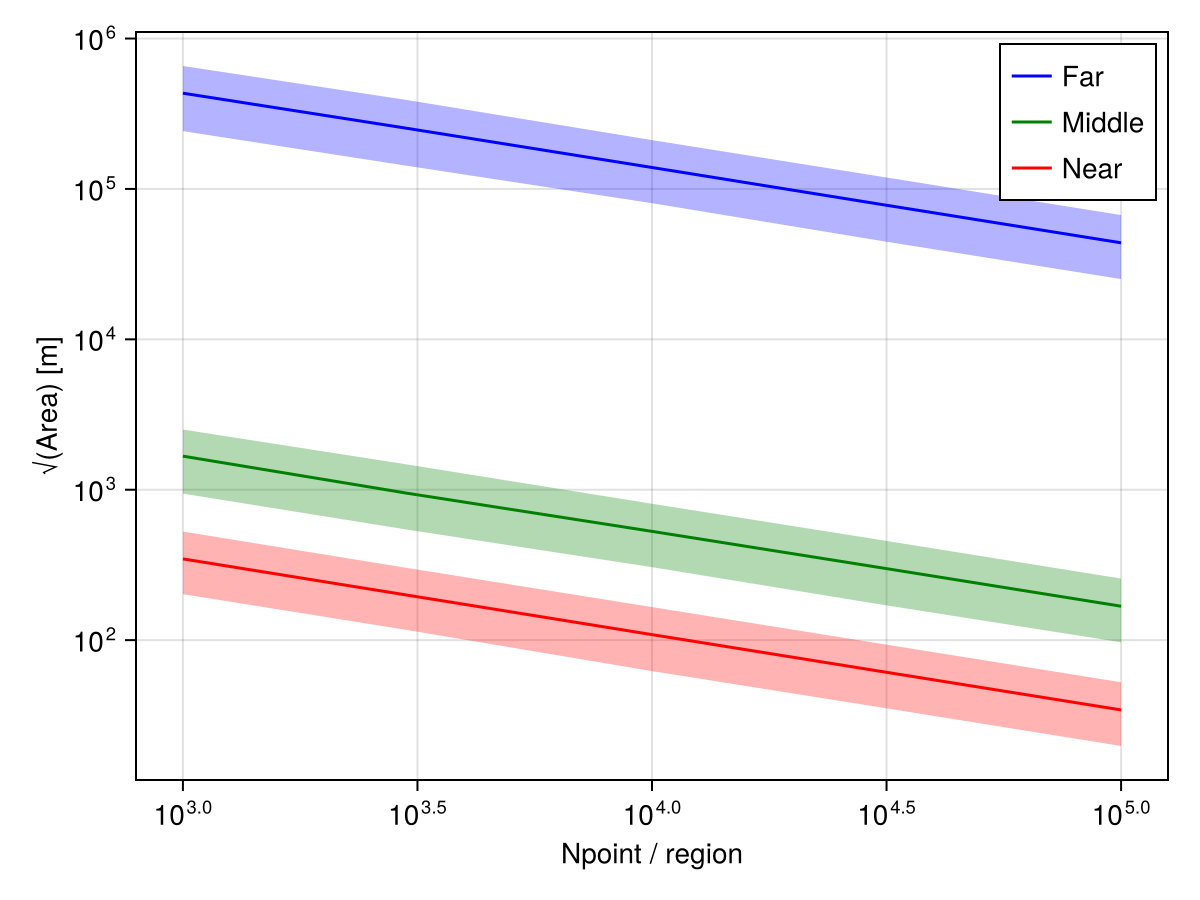

In [42]:
θs = 10_000 / rearth, 50_000 / rearth

ns = [1_000, 3_000, 10_000, 30_000, 100_000]
# ns = [1_000, 3_000, 10_000, 30_000]
outs = zeros((length(ns), 3, 3))

for (idx, N) in enumerate(ns)
    Ns = N, N, N

    sample_points = sample_points_on_sphere(Ns, θs)
    
    triangulation = sphtriangulate(rad2deg.(sample_points), area=true, unit=:km)
    areas1, areas2, areas3 = compute_triangulaiton_areas(triangulation, θs)
    
    outs[idx, 1, :] = sqrt.(quantile(areas1, [0.16, 0.5, 0.84]))
    outs[idx, 2, :] = sqrt.(quantile(areas2, [0.16, 0.5, 0.84]))
    outs[idx, 3, :] = sqrt.(quantile(areas3, [0.16, 0.5, 0.84]))
end

fig = Figure()
ax = Axis(
    fig[1,1],
    xscale=log10,
    yscale=log10,
    xlabel="Npoint / region",
    ylabel="√(Area) [m]",
)

Makie.lines!(ax, ns, outs[:, 3, 2], label="Far", color="blue")
Makie.lines!(ax, ns, outs[:, 2, 2], label="Middle", color="green")
Makie.lines!(ax, ns, outs[:, 1, 2], label="Near", color="red")

Makie.fill_between!(ax, ns, outs[:, 1, 1], outs[:, 1, 3], alpha=0.3, color="red")
Makie.fill_between!(ax, ns, outs[:, 2, 1], outs[:, 2, 3], alpha=0.3, color="green")
Makie.fill_between!(ax, ns, outs[:, 3, 1], outs[:, 3, 3], alpha=0.3, color="blue")

axislegend(ax)

fig

# If we want ~10m resolution, we need to do 1,000,000 points per region
This should give us resolution on the order of 50m in the middle region and 10-20km everywhere else. 
## Warning: This will likely take a few hours, but it only have to happen once.

In [43]:
θtrans1, θtrans2 = 10_000 / rearth, 50_000 / rearth
N1, N2, N3 = 1_000_000, 1_000_000, 1_000_000

sample_points = zeros((N1 + N2 + N3, 2))

for idx in 1:N1
    sinlat = rand(Uniform(cos(θtrans1), 1))
    long = 2π * rand()
    sample_points[idx, :] = [long, asin(sinlat)]
end
    
for idx in 1:N2
    sinlat = rand(Uniform(cos(θtrans2), cos(θtrans1)))
    long = 2π * rand()
    sample_points[idx + N1, :] = [long, asin(sinlat)]
end
    
for idx in 1:N3
    sinlat = rand(Uniform(-1, cos(θtrans2)))
    long = 2π * rand()
    sample_points[idx + N1 + N2, :] = [long, asin(sinlat)]
end

@time triangulation = sphtriangulate(rad2deg.(sample_points), area=true, unit=:km)

10778.767656 seconds (114.00 M allocations: 5.405 GiB, 0.13% gc time)


Vector{GMTdataset{Float64, 2}} with 5999996 segments
Showing first segment. To see other segments just type its element number. e.g. D[2]

Comment:	["sphtriangulate Delaunay output via STRPACK.  Areas in km^2."]
BoundingBox: [21.988960068982795, 22.159668617578347, 89.92936102951784, 89.92955388771188]
Global BoundingBox: [4.637950955288517e-5, 359.9999842493799, -89.87668146972095, 89.9998833294024]
Header:	Triangle: 0 0-972305-923484 Area: 0.000229572 -Z0

3×2 GMTdataset{Float64, 2}
 Row │   col.1    col.2
─────┼──────────────────
   1 │ 22.1597  89.9296
   2 │ 21.989   89.9294
   3 │ 22.1311  89.9294

# Save it to a file
Now that we have this beautiful triangulation, we should save it to a file so that we can reuse it and don't have to run a multi-hour calculation again.

In [7]:
using ProgressMeter

In [32]:
function triangles_to_mesh(triangles)
    # Flatten all triangles into a single vertex list
    all_vertices = vcat(triangles...)
    
    # Find unique vertices and mapping
    unique_vertices = Vector{Float64}[]
    vertex_to_index = Dict{Any, Int}()
    face_indices = Vector{Tuple{Int, Int, Int}}()
    
    current_index = 1
    
    @showprogress for triangle in triangles
        face = Int[]
        for jdx in 1:3
            vertex = triangle[jdx, :]
            if !haskey(vertex_to_index, vertex)
                vertex_to_index[vertex] = current_index
                push!(unique_vertices, vertex)
                push!(face, current_index)
                current_index += 1
            else
                push!(face, vertex_to_index[vertex])
            end
        end
        
        push!(face_indices, (face[1], face[2], face[3]))
    end
    
    return unique_vertices, face_indices
end

triangles_to_mesh (generic function with 2 methods)

In [44]:
vertices, faces = triangles_to_mesh(triangulation)

tmp = zeros((length(vertices), 2))
for idx in 1:length(vertices)
    tmp[idx, :] = vertices[idx]
end
vertices = tmp

tmp = zeros(Int64, (length(faces), 3))
for idx in 1:length(faces)
    tmp[idx, :] .= faces[idx]
end
faces = tmp

h5open("triangulation.h5", "w") do h5f
    group = create_group(h5f, "base_triangulation")
    group["vertices"] = vertices
    group["faces"] = faces
end;

Progress: 100%|█████████████████████████████████████████| Time: 0:00:31
